# Dataset Exploration: QM9 (Preprocessed)


## 1. Initializing Environment & Loading Data


In [12]:
%matplotlib inline

import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data

# Set a larger default font size for plots
plt.rcParams.update({'font.size': 12})

train_pt_path = "../data/qm9/preprocessed/train.pt"
val_pt_path = "../data/qm9/preprocessed/val.pt"
test_pt_path = "../data/qm9/preprocessed/test.pt"
train_json_path = "../data/qm9/preprocessed/train_infos.json"

train_data = torch.load(train_pt_path)
val_data = torch.load(val_pt_path)
test_data = torch.load(test_pt_path)

with open(train_json_path, "r") as f:
    train_infos = json.load(f)

print(f"Loaded {len(train_data)} training samples")
print(f"Loaded {len(val_data)} validation samples")
print(f"Loaded {len(test_data)} test samples")


Loaded 100000 training samples
Loaded 17748 validation samples
Loaded 13083 test samples


## 2. Explanation of Data Preprocessing (`preprocess_qm9.py`)
The original [QM9 dataset](http://quantum-machine.org/datasets/) contains 133,885 molecules with up to 9 heavy atoms (C, O, N, F) stored in `.xyz` format. Every molecule in the raw dataset contains highly detailed computed geometric, energetic, electronic, and thermodynamic properties, such as:

- Dipole moments ($\mu$)
- Isotropic polarizability ($\alpha$)
- HOMO/LUMO energy levels & gap ($\epsilon_{HOMO}, \epsilon_{LUMO}, \Delta\epsilon$)
- Electronic spatial extent ($\\langle R^2 \rangle$)
- Zero point vibrational energy (ZPVE)
- Internal energies ($U_0, U$), Enthalpy ($H$), Free energy ($G$)
- Heat capacity ($C_v$)
- Mulliken partial charges on each atom

### What is stripped away?
If you look at `scripts/preprocess_qm9.py` inside the `process_atoms` function:
```python
def process_atoms(atoms: ase.Atoms):
    def convert_to_pyg():
        data_dict = dict(
            h=torch.LongTensor(atoms.numbers), pos=torch.Tensor(atoms.positions)
        )
        return Data(**data_dict)
```

**ABSOLUTELY EVERYTHING EXCEPT COORDINATES AND ATOMIC TYPES IS DROPPED!** 
The preprocessing script isolates the *pure generation task*. It parses the atomic symbols (`.numbers` mapped to `h`) and their 3D cartesian coordinates (`.positions` mapped to `pos`). All thermodynamic tags, energy levels, partial charges, and global molecular properties are discarded because our generative models ($AADT$ and $VAE$) only care about structural configuration.

It also centers the molecule coordinates at origin (`atoms.positions -= atoms.positions.mean(axis=0)`).


## 3. Structural Inspection of All Attributes
As proven above, the dataset objects are incredibly simple. Let's inspect everything inside them.


In [13]:
sample = train_data[0]

print("Type:", type(sample))
print("Available Attributes:", sample.keys())

print("\nDetailed contents of a single molecule:")
for key in sample.keys():
    val = sample[key]
    if isinstance(val, torch.Tensor):
        print(f" - {key}: Tensor of shape {val.shape}, dtype {val.dtype}")
    else:
        print(f" - {key}: {type(val)} = {val}")

print("\nLet's see the raw values:")
print("Atomic types (h):", sample['h'])
print("Positions (pos):\n", sample['pos'])


Type: <class 'torch_geometric.data.data.Data'>
Available Attributes: ['pos', 'h']

Detailed contents of a single molecule:
 - pos: Tensor of shape torch.Size([5, 3]), dtype torch.float32
 - h: Tensor of shape torch.Size([5]), dtype torch.int64

Let's see the raw values:
Atomic types (h): tensor([6, 1, 1, 1, 1])
Positions (pos):
 tensor([[-9.0199e-06,  7.5058e-06, -4.5820e-07],
        [ 1.4840e-02, -1.0918e+00, -6.0253e-03],
        [ 1.0244e+00,  3.7795e-01, -7.7249e-03],
        [-5.2813e-01,  3.6173e-01, -8.8465e-01],
        [-5.1112e-01,  3.5214e-01,  8.9840e-01]])


## 4. Investigating Atomic Types (`h` Tensor)


In [14]:
try:
    from ase.data import chemical_symbols
    decoder = chemical_symbols
except ImportError:
    decoder = ["Unknown"] * 100
    decoder[1] = "H"
    decoder[6] = "C"
    decoder[7] = "N"
    decoder[8] = "O"
    decoder[9] = "F"

symbols = [decoder[idx] for idx in sample.h]
print(f"Chemical symbols mapped for Molecule 0: {symbols}")


Chemical symbols mapped for Molecule 0: ['C', 'H', 'H', 'H', 'H']


## 5. Visualizing Molecule Coordinates (`pos` Tensor)
Since our data contains spatial coordinates (`pos`), let's plot a few examples to see the internal structure. We will visualize molecules 0, 1000, 2000, and 3000.


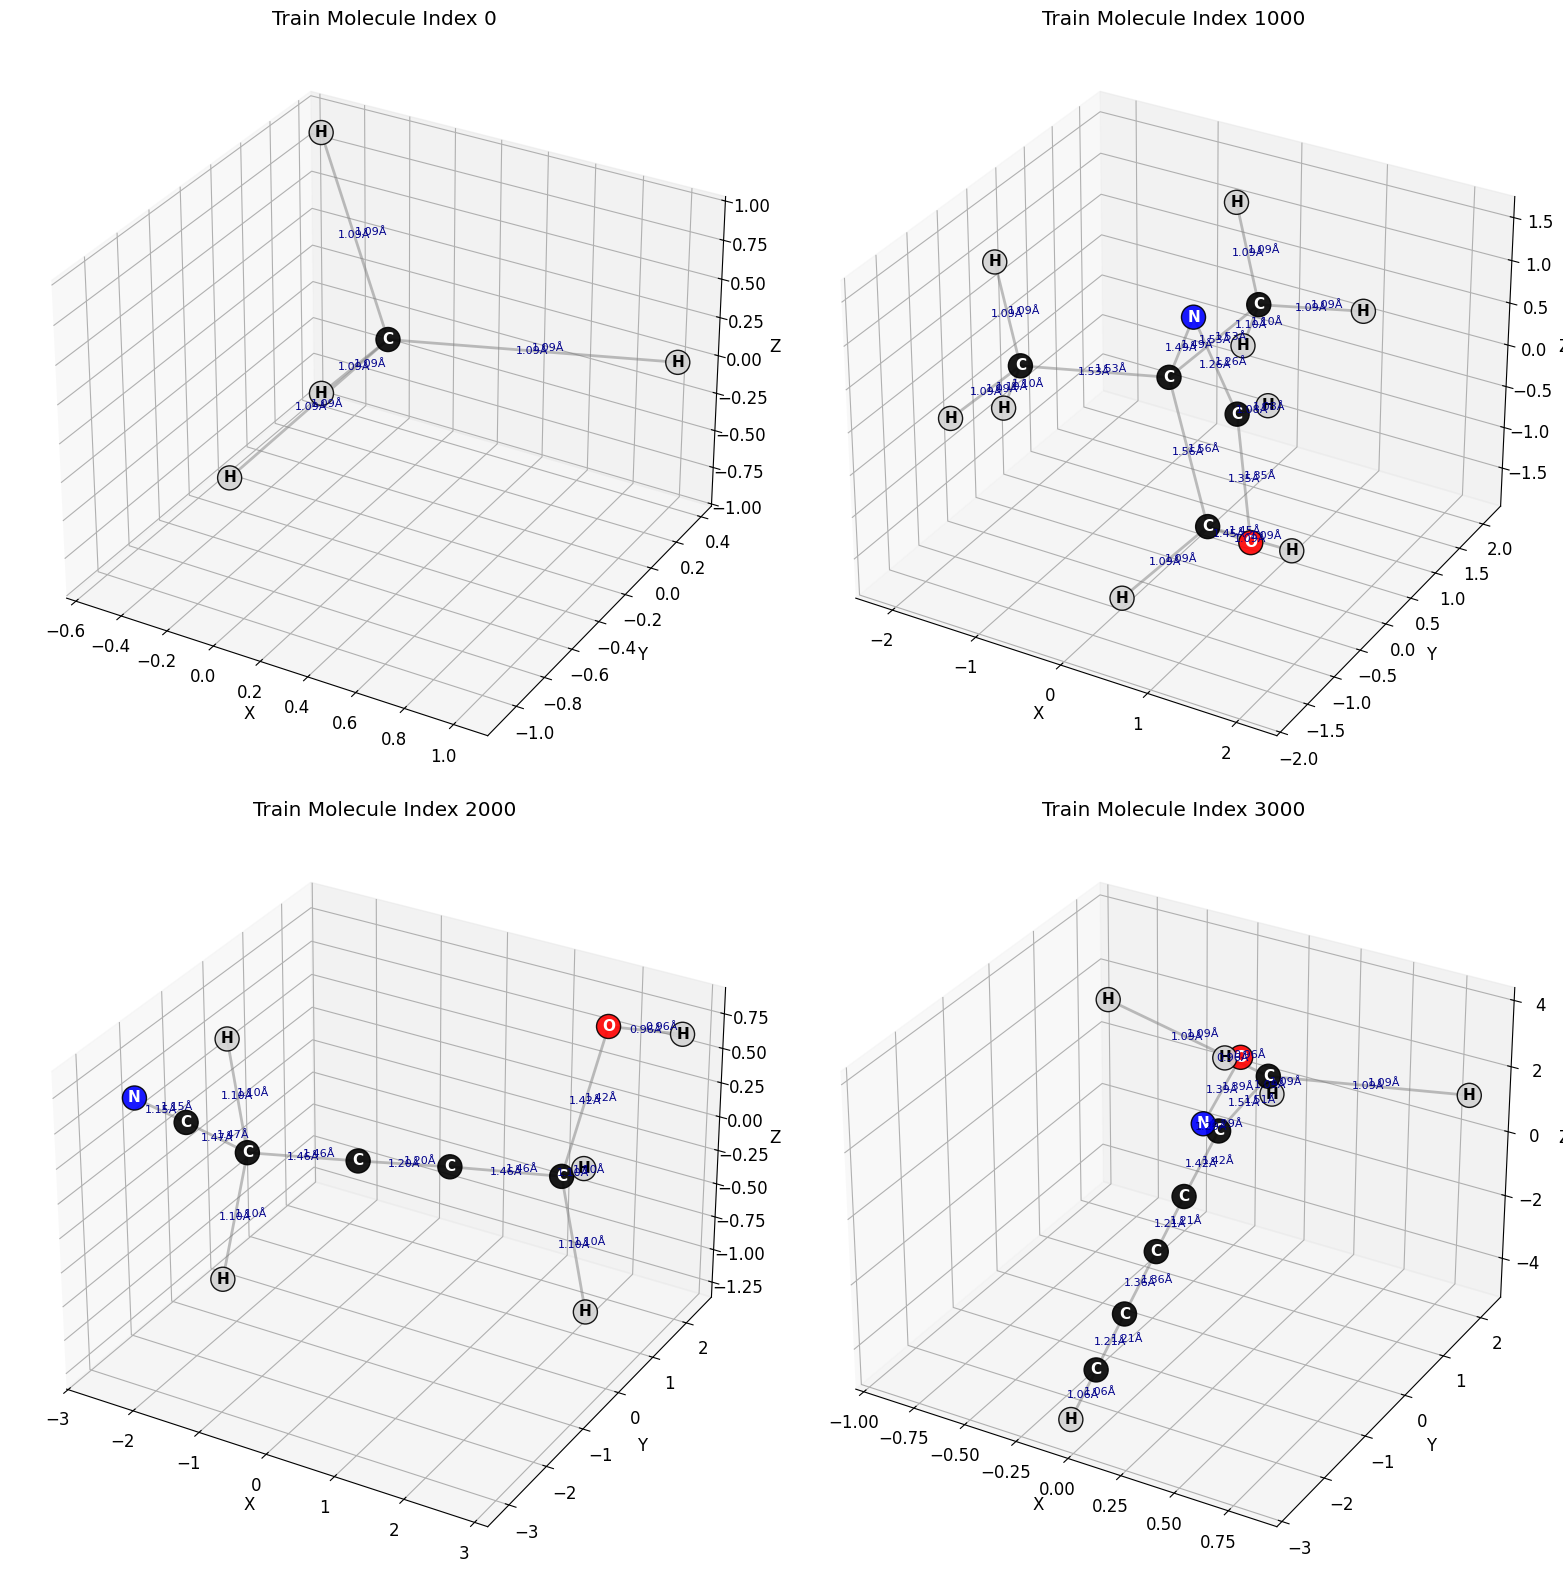

In [15]:
color_map = {
    1: 'lightgray', # H
    6: 'black',     # C
    7: 'blue',      # N
    8: 'red',       # O
    9: 'green'      # F
}

fig = plt.figure(figsize=(16, 16))
sampled_indices = [0, 1000, 2000, 3000]

for idx, data_idx in enumerate(sampled_indices):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    
    data = train_data[data_idx]
    pos = data.pos.numpy()
    types = data.h.numpy()
    
    colors = [color_map.get(t, 'pink') for t in types]
    
    # Draw atoms
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=colors, s=300, edgecolor='black', alpha=0.9)
    
    # Annotate atoms
    for i in range(len(pos)):
        ax.text(pos[i, 0], pos[i, 1], pos[i, 2], decoder[types[i]], 
                fontsize=11, fontweight='bold', color='white' if types[i] != 1 else 'black', 
                ha='center', va='center')
    
    # Draw crude bonds based on distance (< 1.6 Å)
    for i in range(len(pos)):
        for j in range(i + 1, len(pos)):
            dist = np.linalg.norm(pos[i] - pos[j])
            if dist < 1.6:
                ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]], [pos[i,2], pos[j,2]], 
                        color='gray', linewidth=2, alpha=0.5)
                mid_point = (pos[i] + pos[j]) / 2
                ax.text(mid_point[0], mid_point[1], mid_point[2], f"{dist:.2f}Å", fontsize=8, color='darkblue', ha='center', va='center')
                mid_point = (pos[i] + pos[j]) / 2
                ax.text(mid_point[0], mid_point[1], mid_point[2], f"{dist:.2f}Å", fontsize=8, color='darkblue')

    ax.set_title(f"Train Molecule Index {data_idx}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

plt.tight_layout()
plt.show()


## 6. Distribution of Molecule Sizes
Understanding the sequence lengths for generation.


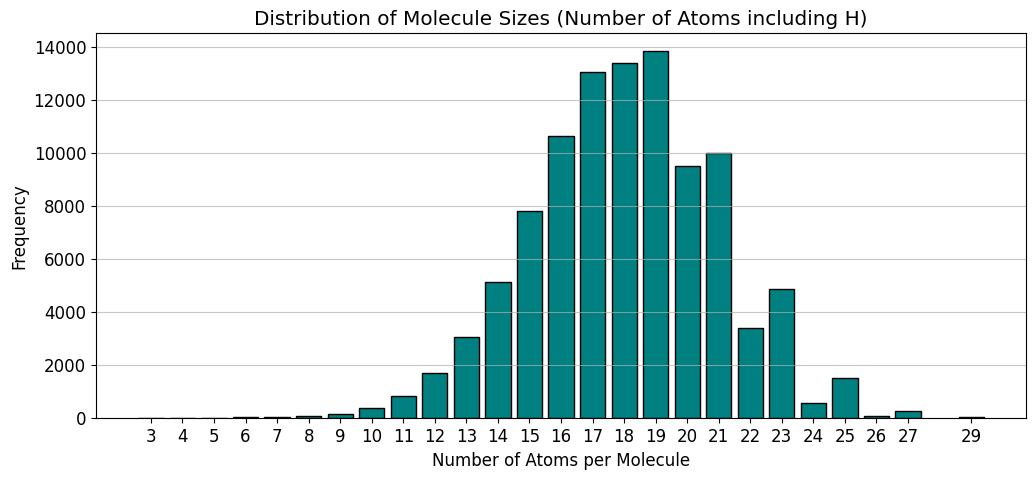

Minimum length: 3
Maximum length: 29
Average length: 18.03


In [16]:
num_atoms_list = [data.h.size(0) for data in train_data]

sizes, counts = np.unique(num_atoms_list, return_counts=True)

plt.figure(figsize=(12, 5))
plt.bar(sizes, counts, color='teal', edgecolor='black')
plt.title("Distribution of Molecule Sizes (Number of Atoms including H)")
plt.xlabel("Number of Atoms per Molecule")
plt.ylabel("Frequency")
plt.xticks(sorted(sizes))
plt.grid(axis='y', alpha=0.7)
plt.show()

print(f"Minimum length: {min(num_atoms_list)}")
print(f"Maximum length: {max(num_atoms_list)}")
print(f"Average length: {np.mean(num_atoms_list):.2f}")


## 7. Composition of Elements Across the Training Set


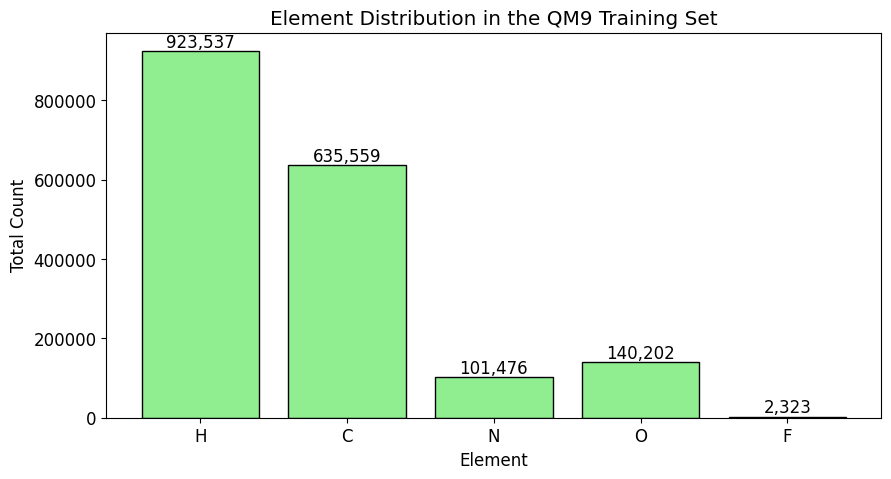

In [17]:
all_elements = []
for data in train_data:
    all_elements.extend(data.h.tolist())

elements, counts = np.unique(all_elements, return_counts=True)
element_symbols = [decoder[e] for e in elements]

plt.figure(figsize=(10, 5))
bars = plt.bar(element_symbols, counts, color='lightgreen', edgecolor='black')
plt.title("Element Distribution in the QM9 Training Set")
plt.xlabel("Element")
plt.ylabel("Total Count")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{int(yval):,}", ha='center', va='bottom')

plt.show()


## 8. Distribution of Coordinates (`pos` Tensor Analysis)
Let's look at the absolute spread of the 3D space occupancy. This helps us ensure that the data is truly centered around $(0,0,0)$ as promised by the preprocessing script.


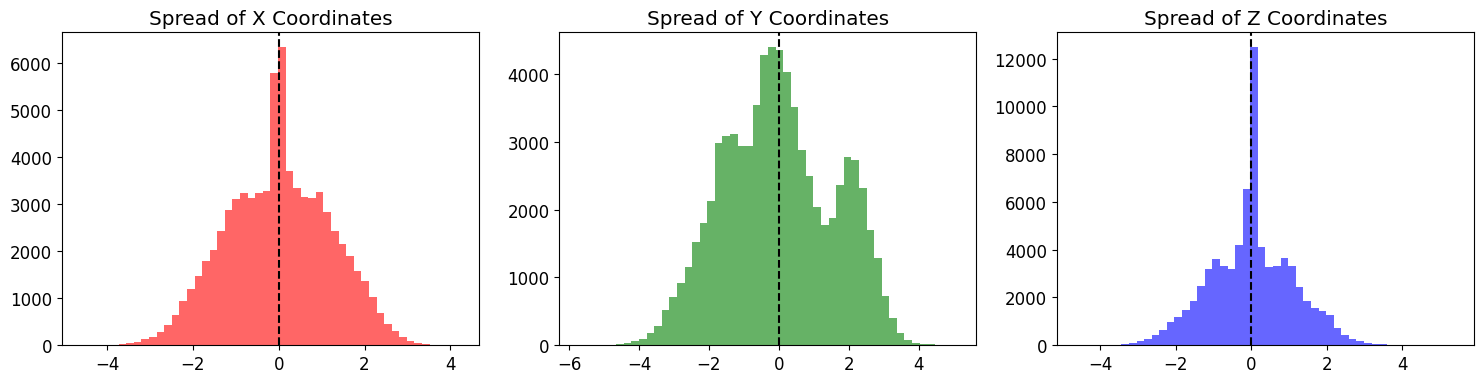

In [18]:
all_x = []
all_y = []
all_z = []

for data in train_data[:5000]:  # sample 5k molecules to avoid memory overload
    pos = data.pos
    all_x.extend(pos[:, 0].tolist())
    all_y.extend(pos[:, 1].tolist())
    all_z.extend(pos[:, 2].tolist())

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(all_x, bins=50, color='red', alpha=0.6)
plt.title("Spread of X Coordinates")
plt.axvline(x=0, color='black', linestyle='--')

plt.subplot(1, 3, 2)
plt.hist(all_y, bins=50, color='green', alpha=0.6)
plt.title("Spread of Y Coordinates")
plt.axvline(x=0, color='black', linestyle='--')

plt.subplot(1, 3, 3)
plt.hist(all_z, bins=50, color='blue', alpha=0.6)
plt.title("Spread of Z Coordinates")
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()


## 9. Pairwise Distances (Bond Length Analysis)
Using the `pos` attribute to determine average bond distances.


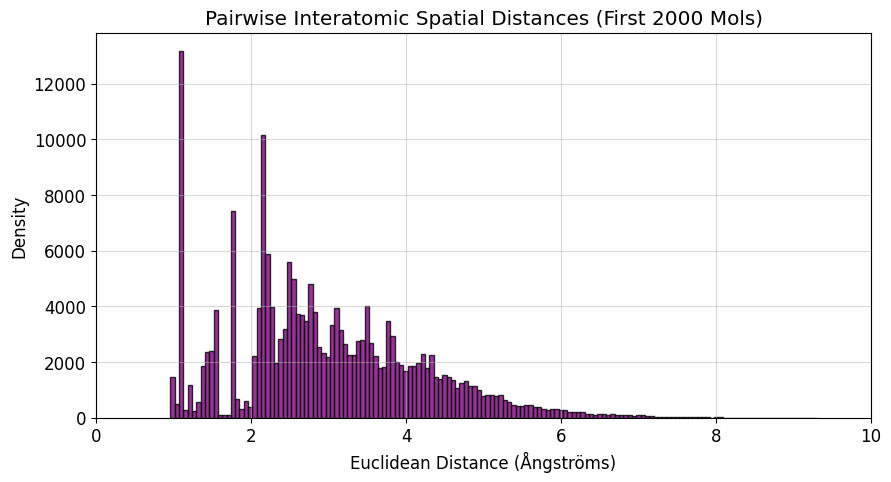

The sharp peaks between 1.0 and 1.5 correspond strictly to standard covalent bond lengths!


In [19]:
pairwise_distances = []

for data in train_data[:2000]:
    pos = data.pos
    dist_matrix = torch.cdist(pos, pos)
    
    # Extract upper triangular values
    indices = torch.triu_indices(len(pos), len(pos), offset=1)
    dists = dist_matrix[indices[0], indices[1]]
    pairwise_distances.extend(dists.tolist())

plt.figure(figsize=(10, 5))
plt.hist(pairwise_distances, bins=150, color='purple', edgecolor='black', alpha=0.8)
plt.title("Pairwise Interatomic Spatial Distances (First 2000 Mols)")
plt.xlabel("Euclidean Distance (Ångströms)")
plt.ylabel("Density")
plt.xlim(0, 10)
plt.grid(alpha=0.5)
plt.show()

print("The sharp peaks between 1.0 and 1.5 correspond strictly to standard covalent bond lengths!")


## 10. Extracting and Analyzing Infos.json
The metadata mappings hold critical details like dataset summary dictionaries.


In [20]:
print("Keys in train_infos.json:", list(train_infos.keys()))

if "atom_hist" in train_infos:
    print("Shape of atom_hist:", np.array(train_infos["atom_hist"]).shape)
    print("atom_hist values:", train_infos["atom_hist"])

if "smiles" in train_infos:
    print(f"\nNumber of reference SMILES dict captures: {len(train_infos['smiles'])}")
    print("Preview of First 5 SMILES strings:")
    for smi in train_infos['smiles'][:5]:
        print("  -", smi)


Keys in train_infos.json: ['atom_stable', 'molecule_stable', 'valid', 'valid_connected', 'valid_unique', 'valid_unique_novel', 'atom_hist', 'num_atoms_hist', 'smiles']
Shape of atom_hist: (5,)
atom_hist values: [0.5121948514139838, 0.35248186869591597, 0.05627872488279887, 0.07775621611039228, 0.0012883388969090403]

Number of reference SMILES dict captures: 97625
Preview of First 5 SMILES strings:
  - [H]C1=C([H])C([H])([H])C(=O)N1C1([H])C([H])([H])C1([H])[H]
  - [H]C1=C([H])C(C([H])([H])[H])(C([H])([H])C([H])([H])[H])C([H])([H])C1=O
  - [H]C([H])([H])N1C2([H])C([H])([H])C13C([H])([H])C([H])([H])OC23[H]
  - [H]Oc1c([H])c([H])c(N([H])[H])n1C([H])([H])[H]
  - [H]N=C1N([H])C2([H])C3([H])OC12C([H])([H])C3([H])[H]


## 11. Density vs Molecular Mass (Correlation using `h` & `pos`)
Let's see if the spread of the positions increases as we pack more heavy atoms into the structure.


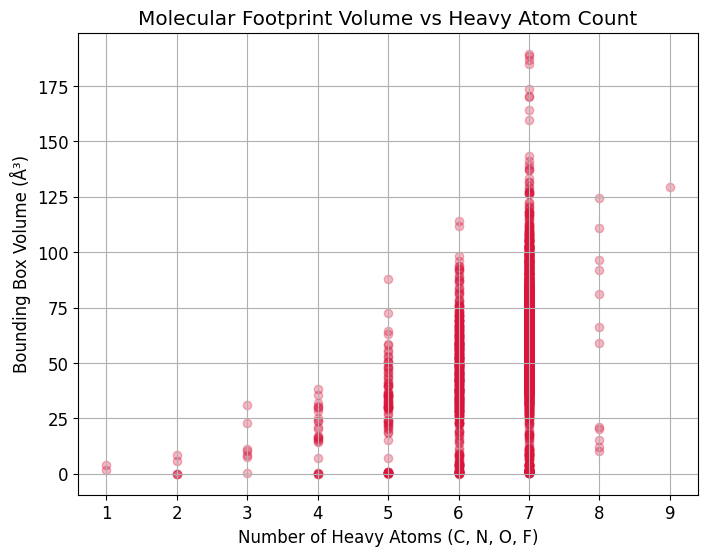

In [21]:
volumes = []
heavy_atom_counts = []

for data in train_data[:3000]:
    pos = data.pos
    types = data.h
    
    # Calculate bounding box volume as a proxy for physical footprint
    vol = (pos[:,0].max() - pos[:,0].min()) * (pos[:,1].max() - pos[:,1].min()) * (pos[:,2].max() - pos[:,2].min())
    volumes.append(vol.item())
    
    # Count heavy atoms (atomic number > 1)
    heavy = (types > 1).sum().item()
    heavy_atom_counts.append(heavy)

plt.figure(figsize=(8, 6))
plt.scatter(heavy_atom_counts, volumes, alpha=0.3, color='crimson')
plt.title("Molecular Footprint Volume vs Heavy Atom Count")
plt.xlabel("Number of Heavy Atoms (C, N, O, F)")
plt.ylabel("Bounding Box Volume (Å³)")
plt.grid(True)
plt.show()


## 9. Interatomic Distance Histograms
Plotting interatomic distances exactly as logged to W&B for C-F, C-H, C-N, C-O, H-N, H-O pairs.

Computing distances for train_data...


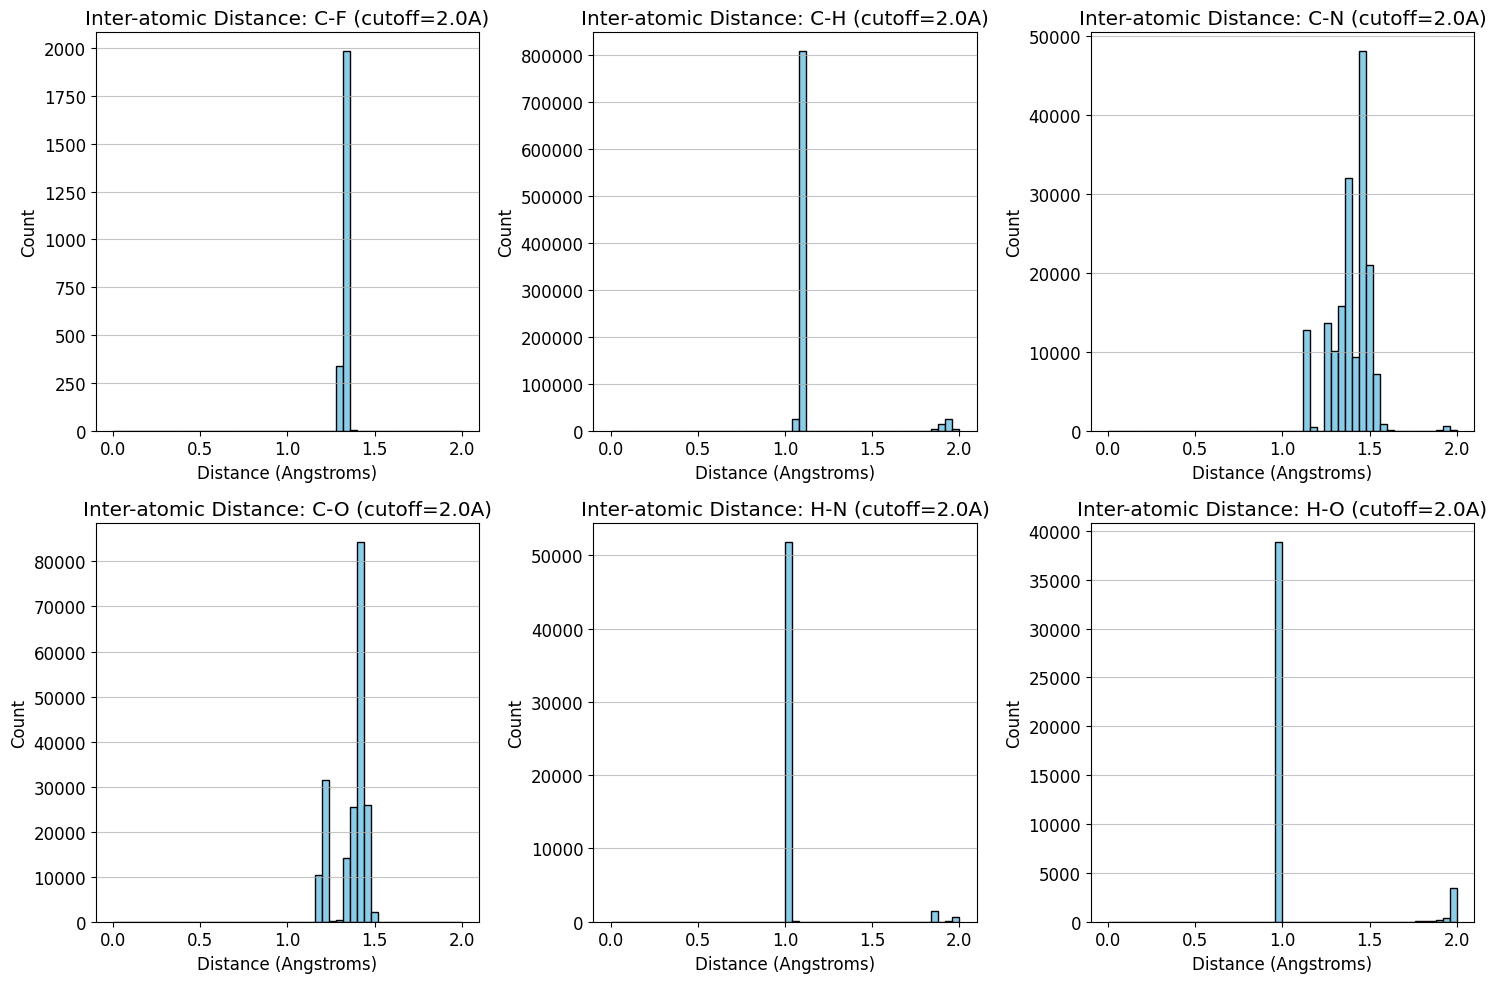

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Rebuild decoder if needed
try:
    from ase.data import chemical_symbols
    decoder = chemical_symbols
except ImportError:
    decoder = ["Unknown"] * 100
    decoder[1] = "H"
    decoder[6] = "C"
    decoder[7] = "N"
    decoder[8] = "O"
    decoder[9] = "F"

allowed_pairs = ["C-F", "C-H", "C-N", "C-O", "H-N", "H-O", "C-C", "N-O"]
distances = {pair_key: [] for pair_key in allowed_pairs}

print("Computing distances for train_data...")
for data in train_data:
    pos = data.pos.numpy()
    types = data.h.numpy()
    symbols = [decoder[t] for t in types]
    n_atoms = len(symbols)
    
    if n_atoms < 2:
        continue
        
    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            dist = np.linalg.norm(pos[i] - pos[j])
            if dist <= 2.0:
                pair = tuple(sorted([symbols[i], symbols[j]]))
                pair_key = f"{pair[0]}-{pair[1]}"
                if pair_key in distances:
                    distances[pair_key].append(dist)

fig, axes = plt.subplots(3, 3, figsize=(15, 15), dpi=100)
axes = axes.flatten()

bins = np.arange(0.5, 2.05, 0.05)
for idx, pair_key in enumerate(allowed_pairs):
    ax = axes[idx]
    dists = distances[pair_key]
    if len(dists) == 0:
        ax.set_title(f"{pair_key} (No data)")
        continue
        
    ax.hist(dists, bins=bins, rwidth=0.6, color='skyblue', edgecolor='black')
    ax.set_title(f"Inter-atomic Distance: {pair_key} (0.5A - 2.0A)")
    ax.set_xlabel("Distance (Angstroms)")
    ax.set_ylabel("Count")
    ax.set_xticks(bins)
    ax.set_xticklabels([f"{x:.2f}" for x in bins], rotation=90)
    ax.set_xlim(0.4, 2.1)
    ax.grid(axis='y', alpha=0.75)

for i in range(len(allowed_pairs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()
